In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# seeing how to load data

In [2]:
DATA_DIR = Path('../data/network_analysis')

network_df_path= DATA_DIR / 'network_df.parquet'
grid_constraint_df_path= DATA_DIR / 'example_grid_constraint_df.parquet'
feeder_block_matrix_path= DATA_DIR / 'feeder_block_matrix.parquet'

In [3]:
network_df = pd.read_parquet(network_df_path)
grid_df = pd.read_parquet(grid_constraint_df_path)
feeder_block_df = pd.read_parquet(feeder_block_matrix_path)

In [ ]:
origin_nodes = network_df['geoid'].unique()
dest_nodes = network_df['neighbor_geoid'].unique()
nodes = list(set(origin_nodes) | set(dest_nodes))
print(f"Total nodes (census block groups): {len(nodes)}")

# Create node demand dictionary
node_demand = {}
for node in nodes:
    # Get demand from origin_demand column
    demand_rows = network_df[network_df['geoid'] == node]
    if len(demand_rows) > 0:
        node_demand[node] = demand_rows['origin_demand_(kW)'].iloc[0]
    else:
        node_demand[node] = 0.0

# Create edges list with costs
edges = []
for idx, row in network_df.iterrows():
    origin = row['geoid']
    neighbor = row['neighbor_geoid']
    # Cost is based on distance (could be weighted differently)
    cost = row['distance_km']
    edges.append((origin, neighbor, cost))

print(f"Total edges: {len(edges)}")

# Prepare feeder data
feeders = list(grid_df['feeder_id'].values)
feeder_capacity = dict(zip(
    grid_df['feeder_id'], 
    grid_df['available_capacity']
))

print(f"Total feeders: {len(feeders)}")

# Create feeder-node mapping from matrix
# The matrix has feeders as rows and GEOIDs as columns
feeder_node_proportion = {}
nodes_represented = set()
for feeder_id in feeder_block_df.index:
    for geoid in feeder_block_df.columns:
        proportion = feeder_block_df.loc[feeder_id, geoid]
        if proportion > 0:
            if feeder_id not in feeder_node_proportion:
                feeder_node_proportion[feeder_id] = {}
            feeder_node_proportion[feeder_id][geoid] = proportion
            nodes_represented.add(geoid)

print(f"Feeder-node mappings created: {len(feeder_node_proportion)}")
print(f"Nodes not mapped to feeders: {len(set(nodes) - nodes_represented)} of {len(nodes)}")


Total nodes (census block groups): 1134
Total edges: 7276
Total feeders: 920


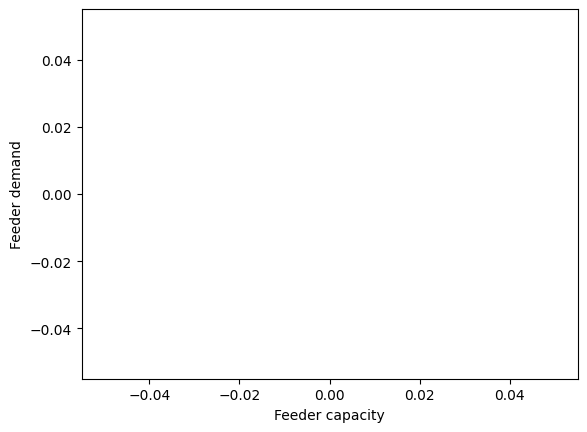

In [ ]:
# fixed int issue
from matplotlib import pyplot as plt
feeder_capacity_lst = []
feeder_demand_lst = []
unmeasured_feeders = 0
for feeder, proportion in feeder_node_proportion.items():
    if feeder not in feeder_capacity.keys():
        unmeasured_feeders += 1
        continue
    feeder_demand = 0
    for k, v in proportion.items():
        if k not in node_demand.keys():
            continue
        # feeder_demand += node_demand[k] * v
        # adding full demand instead of proportion
        feeder_demand += node_demand[k]

    # for plotting
    feeder_capacity_lst.append(feeder_capacity[feeder])
    feeder_demand_lst.append(feeder_demand)

    # if feeder_demand > feeder_capacity:
    #     print(f"Feeder {feeder} is overloaded!")
    #     print(f"Feeder {feeder} demand: {feeder_demand}")
    #     print(f"Feeder {feeder} capacity: {feeder_capacity}")

plt.scatter(feeder_capacity_lst, feeder_demand_lst)
# plot a diaganol line where we'll have overloaded feeders
plt.plot(feeder_capacity_lst, feeder_capacity_lst, 'r--')
plt.xlabel('Feeder capacity')
plt.ylabel('Feeder demand')
plt.show()

# Checking data preparation in optimization

In [1]:
import sys
sys.path.insert(0, '..')
from ev_charger_optimization import EVChargerOptimization

In [2]:
ev = EVChargerOptimization(base_dir='../data/network_analysis')

Loading data files...
Network edges: 7276
Grid feeders: 920
Feeder-block matrix: (3023, 9207)


In [3]:
ev.prepare_data()


Preparing data...
Total nodes (census block groups): 1134
Total edges: 7276
Total feeders: 920
Nodes not mapped to feeders: 0 of 1074
Feeder-node mappings created: 3023
Overloaded feeders: 3


In [4]:
for feeder, proportion in ev.feeder_node_proportion.items():
    proportion_sum = 0
    for k, v in proportion.items():
        proportion_sum += v
    if proportion_sum != 1.0:
        print(f"Feeder {feeder} does not sum to 1.0: {proportion_sum}")

Feeder 012011101 does not sum to 1.0: 0.5208047037085753
Feeder 012011102 does not sum to 1.0: 0.9521262440796446
Feeder 012011103 does not sum to 1.0: 0.6435298851153295
Feeder 012011104 does not sum to 1.0: 0.8455641559018195
Feeder 012011105 does not sum to 1.0: 0.38454028621443154
Feeder 012011106 does not sum to 1.0: 0.9489933426250794
Feeder 012011108 does not sum to 1.0: 2.3898126223879164
Feeder 012011109 does not sum to 1.0: 4.302357118398161
Feeder 012011110 does not sum to 1.0: 0.7603266236312303
Feeder 012011112 does not sum to 1.0: 3.198616344898807
Feeder 012011113 does not sum to 1.0: 2.178334035306526
Feeder 012011114 does not sum to 1.0: 3.366565471900631
Feeder 012011115 does not sum to 1.0: 2.9831982574861304
Feeder 012011116 does not sum to 1.0: 3.4126293536455106
Feeder 012011117 does not sum to 1.0: 1.298221173135023
Feeder 012011118 does not sum to 1.0: 0.9619260338089679
Feeder 012011119 does not sum to 1.0: 0.16253788757193363
Feeder 012011120 does not sum to 1

In [10]:
ev.feeder_node_proportion.keys()

dict_keys(['012011101', '012011102', '012011103', '012011104', '012011105', '012011106', '012011108', '012011109', '012011110', '012011112', '012011113', '012011114', '012011115', '012011116', '012011117', '012011118', '012011119', '012011120', '012011121', '012011132', '012011133', '012011134', '012021103', '012021104', '012022211', '012022212', '012022213', '012022214', '012022215', '012022216', '012022217', '012022218', '012040406', '012040407', '012040408', '012040410', '012041101', '012041102', '012041103', '012041104', '012041105', '012041106', '012041107', '012041110', '012041111', '012041112', '012041115', '012041116', '012041117', '012041130', '012041131', '012041132', '012041133', '012041134', '012060401', '012060402', '012060403', '012060404', '012060405', '012060406', '012060407', '012060408', '012060409', '012060410', '012060411', '012061102', '012061103', '012061105', '012080401', '012080402', '012090401', '012090403', '012090408', '012090409', '012091101', '012091102', '

In [12]:
set(ev.feeder_capacity.keys()) - set(ev.feeder_node_proportion.keys())

set()

In [13]:
# feeder node proportion is a super set of the feeder capacity - may just make it zero
set(ev.feeder_node_proportion.keys()) - set(ev.feeder_capacity.keys())

{'022130407',
 '062041106',
 '042461101',
 '182611102',
 '022101106',
 '013761102',
 '013840404',
 '082831109',
 '253481102',
 '182381104',
 '083892105',
 '013652116',
 '022090409',
 '024020406',
 '082031111',
 '022090410',
 '024020403',
 '082241105',
 '082261107',
 '014101105',
 '063601104',
 '252281111',
 '254242103',
 '062061105',
 '012501110',
 '082951101',
 '042891101',
 '013471130',
 '022571116',
 '192121106',
 '063601107',
 '014321101',
 '083801103',
 '083330411',
 '062081104',
 '013761106',
 '042450413',
 '083622105',
 '252561101',
 '022480401',
 '182191101',
 '063131106',
 '254552102',
 '043291104',
 '024040404',
 '255361106',
 '013532109',
 '012040410',
 '042571102',
 '042021102',
 '022100401',
 '083421112',
 '042561107',
 '252161107',
 '043191101',
 '153132101',
 '182742102',
 '063621108',
 '063621105',
 '022090405',
 '022801134',
 '022011111',
 '192021121',
 '024190408',
 '063601110',
 '082241104',
 '255371118',
 '022340402',
 '083531105',
 '082831104',
 '043361102',
 '1923

In [34]:
feeder_nodes = set()
for feeder, proportion in ev.feeder_node_proportion.items():
    for node, amount in proportion.items():
        feeder_nodes.add(node)

In [35]:
set(ev.node_demand.keys()) - feeder_nodes

set()

In [40]:
feeder_nodes - set(ev.node_demand.keys())

{'060750124051',
 '060610239002',
 '061070004012',
 '061150402024',
 '060133452052',
 '060816103041',
 '060890108052',
 '060750228021',
 '060530136003',
 '060290024032',
 '060133830001',
 '060952531055',
 '060816028002',
 '060750178011',
 '060133451021',
 '060070035014',
 '060070024012',
 '060855035041',
 '060770053103',
 '060290041023',
 '060790125053',
 '060790110022',
 '060133551252',
 '060190038102',
 '060971539041',
 '060390002042',
 '060790125034',
 '060290027023',
 '060855009013',
 '060750211001',
 '060890110022',
 '060450118002',
 '060855037072',
 '060952532051',
 '060530001032',
 '060790109042',
 '060952524014',
 '060530145003',
 '060133190012',
 '061030009001',
 '060855042012',
 '060470020011',
 '060390007022',
 '060750167002',
 '060390005062',
 '060855122001',
 '060530112022',
 '060855119131',
 '060871006002',
 '060855027032',
 '060750479031',
 '060952514001',
 '060855032102',
 '060770041072',
 '060816076001',
 '060855002002',
 '060290003001',
 '060290027021',
 '060816023001

In [48]:
len(feeder_nodes - ev.node_demand.keys())

8133

In [51]:
len(set([int(k) for k in feeder_nodes]) - set([int(k) for k in ev.node_demand.keys()]))

8133

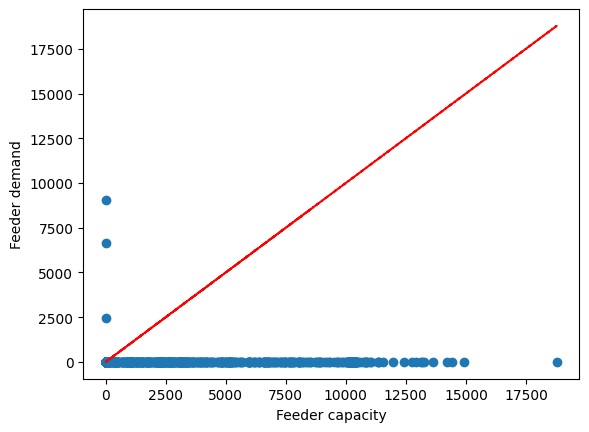

In [43]:
# fixed int issue
from matplotlib import pyplot as plt
feeder_capacity_lst = []
feeder_demand_lst = []
unmeasured_feeders = 0
for feeder, proportion in ev.feeder_node_proportion.items():
    if feeder not in ev.feeder_capacity.keys():
        unmeasured_feeders += 1
        continue
    feeder_demand = 0
    feeder_capacity = ev.feeder_capacity[feeder]
    for k, v in proportion.items():
        if k not in ev.node_demand.keys():
            continue
        # feeder_demand += ev.node_demand[k] * v
        # adding full demand instead of proportion
        feeder_demand += ev.node_demand[k]

    # for plotting
    feeder_capacity_lst.append(feeder_capacity)
    feeder_demand_lst.append(feeder_demand)

    # if feeder_demand > feeder_capacity:
    #     print(f"Feeder {feeder} is overloaded!")
    #     print(f"Feeder {feeder} demand: {feeder_demand}")
    #     print(f"Feeder {feeder} capacity: {feeder_capacity}")

plt.scatter(feeder_capacity_lst, feeder_demand_lst)
# plot a diaganol line where we'll have overloaded feeders
plt.plot(feeder_capacity_lst, feeder_capacity_lst, 'r--')
plt.xlabel('Feeder capacity')
plt.ylabel('Feeder demand')
plt.show()

In [10]:
unmeasured_feeders/len(ev.feeder_node_proportion.keys())

0.6956665564009262

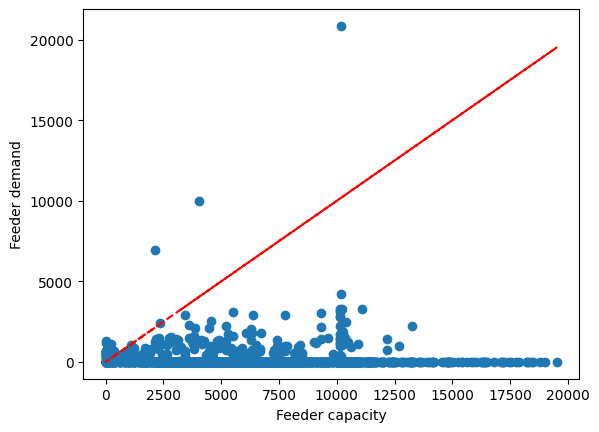

In [ ]:
# does this change if we normalize sum of matrices to 0? 
for feeder, proportion in ev.feeder_node_proportion.items():
    total_proportion = 0
    for k, v in proportion.items():
        total_proportion += v
    for k, v in proportion.items():
        proportion[k] = v / total_proportion

from matplotlib import pyplot as plt
feeder_capacity_lst = []
feeder_demand_lst = []
for feeder, proportion in ev.feeder_node_proportion.items():
    if int(feeder) not in ev.feeder_capacity.keys():
        continue
    feeder_demand = 0
    feeder_capacity = ev.feeder_capacity[int(feeder)]
    for k, v in proportion.items():
        if k not in ev.node_demand.keys():
            continue
        feeder_demand += ev.node_demand[k] * v

    # for plotting
    feeder_capacity_lst.append(feeder_capacity)
    feeder_demand_lst.append(feeder_demand)

    # if feeder_demand > feeder_capacity:
    #     print(f"Feeder {feeder} is overloaded!")
    #     print(f"Feeder {feeder} demand: {feeder_demand}")
    #     print(f"Feeder {feeder} capacity: {feeder_capacity}")

plt.scatter(feeder_capacity_lst, feeder_demand_lst)
# plot a diaganol line where we'll have overloaded feeders
plt.plot(feeder_capacity_lst, feeder_capacity_lst, 'r--')
plt.xlabel('Feeder capacity')
plt.ylabel('Feeder demand')
plt.show()

In [61]:
ev.grid_df.feeder_id.astype('str')

892      82832114
1680    252411104
1618    252052110
1036     83801111
596      42031125
          ...    
1561    182981102
660      42681102
1575    183582101
1122    103181102
1691    252531102
Name: feeder_id, Length: 1969, dtype: object